# Price-based features

Mid, rolling volatility (`vol_50`), and microprice tilt over a 10-minute window.

In [33]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())

cwd: /home/johnh/projects/microstructure-benchmark


In [34]:
import matplotlib.pyplot as plt
import polars as pl
from src.features import add_returns, add_rolling_vol, add_microprice_tilt

lf = pl.scan_parquet("data/parquet/mnq_bars100ms_2025-09-15.parquet").filter(
    (pl.col("ts_event") >= pl.lit("2025-09-15T14:00:00").str.to_datetime(time_zone="UTC"))
    & (pl.col("ts_event") < pl.lit("2025-09-15T14:10:00").str.to_datetime(time_zone="UTC"))
)
df = add_microprice_tilt(add_rolling_vol(add_returns(lf), [50])).collect()
print("rows:", df.height)

rows: 5936


saved: /home/johnh/projects/microstructure-benchmark/notebooks/figures/features_10min.png


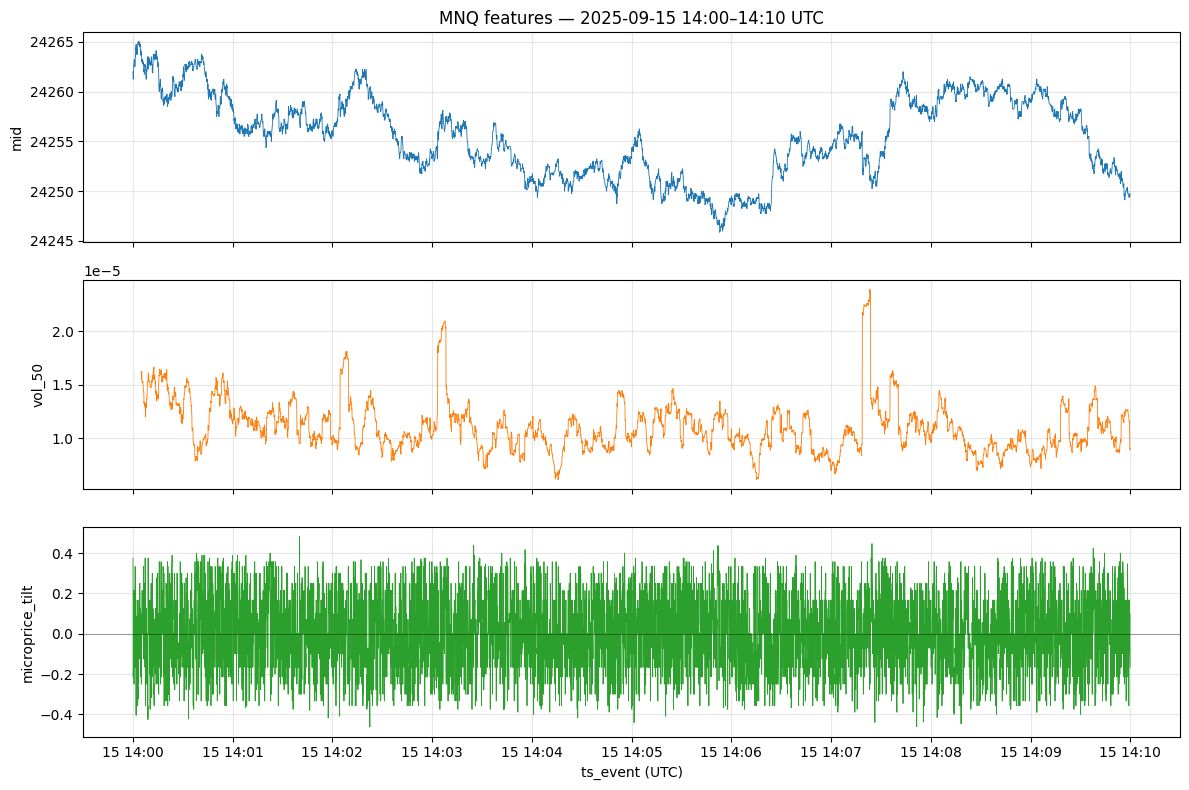

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df["ts_event"], df["mid"], linewidth=0.6)
axes[0].set_ylabel("mid")
axes[0].set_title("MNQ features — 2025-09-15 14:00–14:10 UTC")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["ts_event"], df["vol_50"], linewidth=0.6, color="C1")
axes[1].set_ylabel("vol_50")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["ts_event"], df["microprice_tilt"], linewidth=0.6, color="C2")
axes[2].set_ylabel("microprice_tilt")
axes[2].set_xlabel("ts_event (UTC)")
axes[2].axhline(0, color="k", linewidth=0.5, alpha=0.5)
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
out = Path("notebooks/figures/features_10min.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=120)
print("saved:", out.resolve())
plt.show()

# Order flow imbalance vs forward return

`ofi_sum_1000ms` vs 1-second forward mid log-return. Expect a **positive** correlation.

corr=-0.0054 n=20,374
saved: /home/johnh/projects/microstructure-benchmark/notebooks/figures/ofi_vs_fwd_return.png


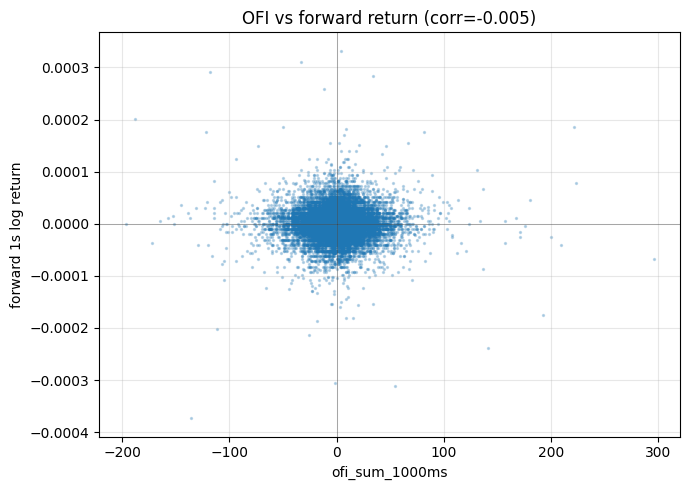

In [36]:
import numpy as np

lf = pl.scan_parquet("data/parquet/mnq_bars100ms_2025-09-15.parquet")
df = (
    lf.with_columns(
        (pl.col("mid").shift(-10) / pl.col("mid")).log().alias("fwd_ret_1s")
    )
    .select(["ofi_sum_1000ms", "fwd_ret_1s"])
    .drop_nulls()
    .collect()
)
step = max(1, df.height // 20_000)
plot = df[::step]
corr = np.corrcoef(plot["ofi_sum_1000ms"].to_numpy(), plot["fwd_ret_1s"].to_numpy())[0, 1]
print(f"corr={corr:.4f} n={plot.height:,}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot["ofi_sum_1000ms"], plot["fwd_ret_1s"], s=2, alpha=0.25)
ax.set_xlabel("ofi_sum_1000ms")
ax.set_ylabel("forward 1s log return")
ax.set_title(f"OFI vs forward return (corr={corr:.3f})")
ax.axhline(0, color="k", lw=0.5, alpha=0.4)
ax.axvline(0, color="k", lw=0.5, alpha=0.4)
ax.grid(True, alpha=0.3)
fig.tight_layout()
out = Path("notebooks/figures/ofi_vs_fwd_return.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=120)
print("saved:", out.resolve())
plt.show()

In [37]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

# notebook lives in notebooks/ — make sure cwd is repo root
ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)

from src.features import FEATURES

day = "2025-09-16"
df = pl.read_parquet(f"data/parquet/mnq_features_{day}.parquet")
print(df.shape)
print(df.select(FEATURES).head(3))

(330848, 16)
shape: (3, 12)
┌────────────┬────────────┬───────────┬────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ microprice ┆ spread_bps ┆ rel_sprea ┆ vol_10 ┆ … ┆ ofi_sum_1 ┆ ofi_sum_5 ┆ trade_imb ┆ kyle_lamb │
│ _tilt      ┆ ---        ┆ d         ┆ ---    ┆   ┆ 000ms     ┆ 000ms     ┆ _50       ┆ da_50     │
│ ---        ┆ f64        ┆ ---       ┆ f64    ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64        ┆            ┆ f64       ┆        ┆   ┆ i64       ┆ i64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪═══════════╪════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ -0.375     ┆ 0.205717   ┆ null      ┆ null   ┆ … ┆ null      ┆ null      ┆ null      ┆ null      │
│ -0.375     ┆ 0.205717   ┆ null      ┆ null   ┆ … ┆ null      ┆ null      ┆ null      ┆ null      │
│ -0.136364  ┆ 0.308577   ┆ null      ┆ null   ┆ … ┆ null      ┆ null      ┆ null      ┆ null      │
└────────────┴────────────┴───────────┴────────┴───┴───────────

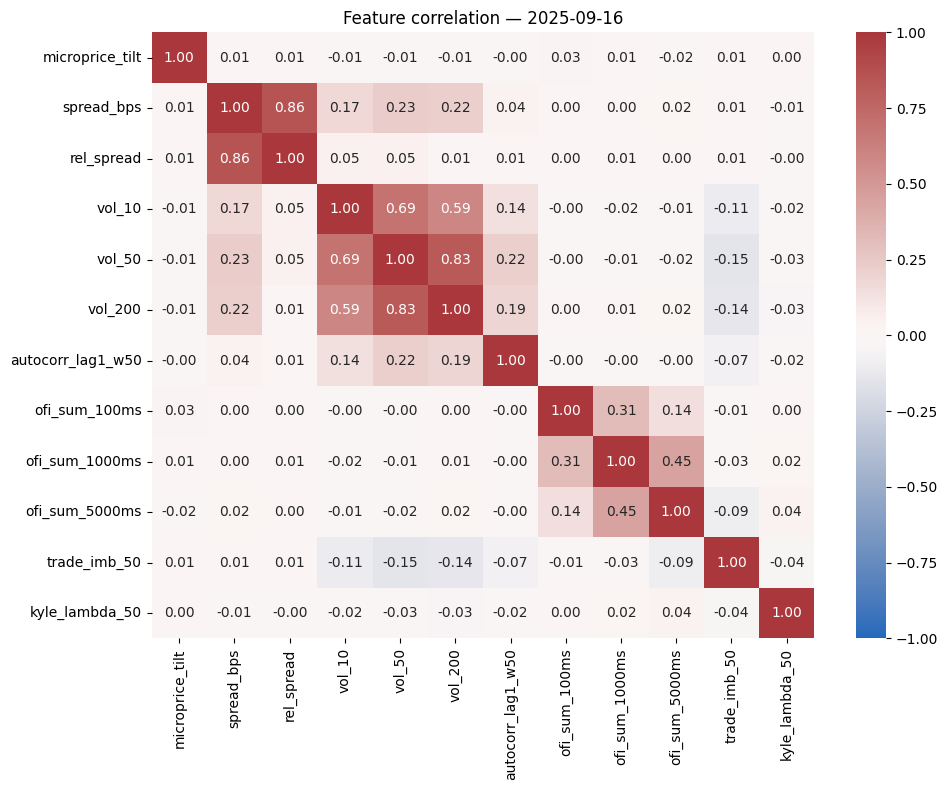

In [38]:
corr = df.select(FEATURES).drop_nulls().to_pandas().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title(f"Feature correlation — {day}")
plt.tight_layout()
plt.show()

In [39]:
from pathlib import Path
import os

import polars as pl

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)

paths = sorted(Path("data/parquet").glob("mnq_features_*.parquet"))
df = pl.concat([pl.scan_parquet(p) for p in paths]).collect()
print(f"days={len(paths)} rows={df.height:,} cols={df.width}")
print(df.columns)

days=17 rows=5,957,250 cols=16
['ts_event', 'mid', 'microprice_tilt', 'spread_bps', 'rel_spread', 'vol_10', 'vol_50', 'vol_200', 'autocorr_lag1_w50', 'ofi_sum_100ms', 'ofi_sum_1000ms', 'ofi_sum_5000ms', 'trade_imb_50', 'kyle_lambda_50', 'label_tb', 'label_fr']


In [40]:
def class_balance(s: pl.Series, name: str) -> None:
    vc = s.value_counts().sort(s.name)
    total = s.len()
    print(f"\n=== {name} ===")
    for row in vc.iter_rows(named=True):
        lab = row[s.name]
        n = row["count"]
        print(f"  {lab:+d}: {n:,}  ({100 * n / total:5.1f}%)")

class_balance(df["label_tb"], "label_tb (triple-barrier)")
class_balance(df["label_fr"], "label_fr (forward-return)")


=== label_tb (triple-barrier) ===
  -1: 2,128,590  ( 35.7%)
  +0: 1,695,588  ( 28.5%)
  +1: 2,133,072  ( 35.8%)

=== label_fr (forward-return) ===
  -1: 396,818  (  6.7%)
  +0: 5,156,347  ( 86.6%)
  +1: 404,085  (  6.8%)


# Cumulative log-likelihood gain (test day)

Load `data/results/single_split_compare.parquet` from `scripts/compare_models.py`.
Naive baseline = always predict class **0** (flat / label `0`) with nearly all mass on that class.
Gain = `cumsum(log p_model[y] - log p_naive[y])` over the test day.

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

if Path.cwd().name == "notebooks":
    os.chdir("..")

pred_path = Path("data/results/single_split_compare.parquet")
if not pred_path.exists():
    raise FileNotFoundError(
        f"Missing {pred_path}. Run: .venv/bin/python scripts/compare_models.py"
    )

df = pl.read_parquet(pred_path).sort("ts_event")
y = df["y_cls"].to_numpy().astype(np.int64)

eps = 1e-6
# Always-predict-flat: nearly all mass on class 1 (label 0).
p_naive = np.array([eps / 2, 1.0 - eps, eps / 2], dtype=np.float64)

def _model_probs(prefix: str) -> np.ndarray:
    return np.column_stack(
        [
            df[f"{prefix}_p_down"].to_numpy(),
            df[f"{prefix}_p_zero"].to_numpy(),
            df[f"{prefix}_p_up"].to_numpy(),
        ]
    ).astype(np.float64)

def _cum_ll_gain(probs: np.ndarray, y: np.ndarray, p_naive: np.ndarray) -> np.ndarray:
    probs = np.clip(probs, eps, 1.0)
    probs = probs / probs.sum(axis=1, keepdims=True)
    ll_m = np.log(probs[np.arange(len(y)), y])
    ll_n = np.log(p_naive[y])
    return np.cumsum(ll_m - ll_n)

gain_xgb = _cum_ll_gain(_model_probs("xgb"), y, p_naive)
gain_lstm = _cum_ll_gain(_model_probs("lstm"), y, p_naive)
ts = df["ts_event"].to_numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts, gain_xgb, label="XGBoost", linewidth=1.0)
ax.plot(ts, gain_lstm, label="LSTM", linewidth=1.0)
ax.axhline(0.0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative log-likelihood gain vs always-predict-0 (test day)")
ax.set_xlabel("ts_event")
ax.set_ylabel("cum LL gain")
ax.legend()
fig.tight_layout()
plt.show()

print(f"final LL gain — xgb: {gain_xgb[-1]:.1f}, lstm: {gain_lstm[-1]:.1f}")
print(f"bars: {len(y):,}")
